In [16]:
import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))


/kaggle/input/datasets/uciml/breast-cancer-wisconsin-data/data.csv


In [17]:
df = pd.read_csv('/kaggle/input/datasets/uciml/breast-cancer-wisconsin-data/data.csv')

In [18]:
df.sample(4)

,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Unnamed: 32
252,885429,M,19.73,19.82,130.70,1206.0,0.10620,0.18490,0.24170,0.09740,...,25.59,159.80,1933.0,0.17100,0.5955,0.8489,0.25070,0.2749,0.12970,NaN
519,917080,B,12.75,16.70,82.51,493.8,0.11250,0.11170,0.03880,0.02995,...,21.74,93.63,624.1,0.14750,0.1979,0.1423,0.08045,0.3071,0.08557,NaN
216,8811523,B,11.89,18.35,77.32,432.2,0.09363,0.11540,0.06636,0.03142,...,27.10,86.20,531.2,0.14050,0.3046,0.2806,0.11380,0.3397,0.08365,NaN
157,8711216,B,16.84,19.46,108.40,880.2,0.07445,0.07223,0.05150,0.02771,...,28.07,120.30,1032.0,0.08774,0.1710,0.1882,0.08436,0.2527,0.05972,NaN


In [19]:
df.drop(columns = ['id','Unnamed: 32'],inplace=True)

In [20]:
df.sample(5)

,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
371,B,15.19,13.21,97.65,711.8,0.07963,0.06934,0.03393,0.026570,0.1721,...,16.20,15.73,104.50,819.1,0.1126,0.17370,0.13620,0.08178,0.2487,0.06766
425,B,10.03,21.28,63.19,307.3,0.08117,0.03912,0.00247,0.005159,0.1630,...,11.11,28.94,69.92,376.3,0.1126,0.07094,0.01235,0.02579,0.2349,0.08061
194,M,14.86,23.21,100.40,671.4,0.10440,0.19800,0.16970,0.088780,0.1737,...,16.08,27.78,118.60,784.7,0.1316,0.46480,0.45890,0.17270,0.3000,0.08701
281,B,11.74,14.02,74.24,427.3,0.07813,0.04340,0.02245,0.027630,0.2101,...,13.31,18.26,84.70,533.7,0.1036,0.08500,0.06735,0.08290,0.3101,0.06688
439,B,14.02,15.66,89.59,606.5,0.07966,0.05581,0.02087,0.026520,0.1589,...,14.91,19.31,96.53,688.9,0.1034,0.10170,0.06260,0.08216,0.2136,0.06710


In [21]:
df['diagnosis'] = df['diagnosis'].map({'M': 1, 'B': 0})

In [22]:
df.sample(5)

,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
483,0,13.70,17.64,87.76,571.1,0.0995,0.07957,0.04548,0.03160,0.1732,...,14.96,23.53,95.78,686.5,0.1199,0.1346,0.1742,0.09077,0.2518,0.06960
507,0,11.06,17.12,71.25,366.5,0.1194,0.10710,0.04063,0.04268,0.1954,...,11.69,20.74,76.08,411.1,0.1662,0.2031,0.1256,0.09514,0.2780,0.11680
352,1,25.73,17.46,174.20,2010.0,0.1149,0.23630,0.33680,0.19130,0.1956,...,33.13,23.58,229.30,3234.0,0.1530,0.5937,0.6451,0.27560,0.3690,0.08815
203,1,13.81,23.75,91.56,597.8,0.1323,0.17680,0.15580,0.09176,0.2251,...,19.20,41.85,128.50,1153.0,0.2226,0.5209,0.4646,0.20130,0.4432,0.10860
478,0,11.49,14.59,73.99,404.9,0.1046,0.08228,0.05308,0.01969,0.1779,...,12.40,21.90,82.04,467.6,0.1352,0.2010,0.2596,0.07431,0.2941,0.09180


In [23]:
X = df.drop(columns = ['diagnosis'])
y = df['diagnosis']

In [34]:
import tensorflow
from tensorflow import keras
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.layers import Dropout
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from tensorflow.keras.callbacks import EarlyStopping

In [26]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size = 0.2,random_state = 42)

In [28]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [31]:
model = Sequential()
model.add(Dense(12,activation = 'relu',input_dim = 30))  #Hidden layers
model.add(Dense(12,activation = 'relu')) #Hidden layers
model.add(Dense(1,activation = 'sigmoid')) #output layers

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
2026-09-02 07:26:16.104044: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


In [32]:

model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 12)             │           372 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 12)             │           156 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            13 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 541 (2.11 KB)

 Trainable params: 541 (2.11 KB)

 Non-trainable params: 0 (0.00 B)

In [33]:
model.compile(loss='binary_crossentropy',optimizer ='Adam',metrics = ['accuracy'])

In [36]:
# callback = EarlyStopping(
#     monitor = 'val_loss',
#     min_delta = 0.0001,
#     patience = 2,
#     verbose = 1,
#     mode = 'auto',
#     baseline = None,
#     restore_best_weights  =False
# )

In [40]:
history = model.fit(X_train_scaled, y_train, validation_data=(X_test_scaled, y_test), epochs=500, verbose=1) #epoch=500 for overfitting

Epoch 1/500
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.9934 - loss: 0.0291 - val_accuracy: 0.9561 - val_loss: 0.0921
Epoch 2/500
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9912 - loss: 0.0282 - val_accuracy: 0.9474 - val_loss: 0.0954
Epoch 3/500
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9912 - loss: 0.0277 - val_accuracy: 0.9474 - val_loss: 0.0980
Epoch 4/500
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9934 - loss: 0.0272 - val_accuracy: 0.9561 - val_loss: 0.0931
Epoch 5/500
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9934 - loss: 0.0263 - val_accuracy: 0.9561 - val_loss: 0.0945
Epoch 6/500
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9934 - loss: 0.0257 - val_accuracy: 0.9561 - val_loss: 0.0949
Epoch 7/500
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9934 - loss: 0.0252 - val_accuracy: 0.9561 - val_loss: 0.0952
Epoch 8/500
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9934 - loss: 0.0247 - val_accuracy: 0.9474 - 

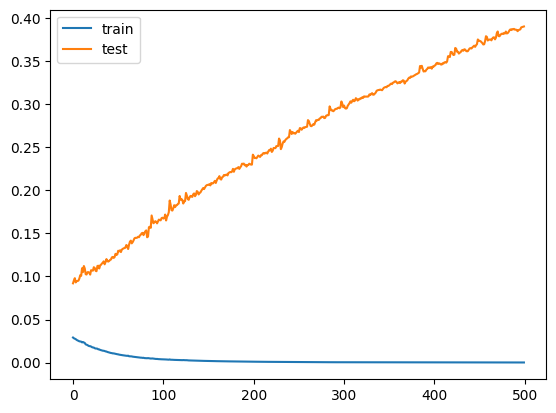

In [41]:
plt.plot(history.history['loss'], label='train')
plt.plot(history.history['val_loss'], label='test')
plt.legend()
plt.show()

# APPLYING DROPOUTS:

In [42]:
model = Sequential()

model.add(Dense(12, input_dim=30, activation='relu'))
model.add(Dropout(0.5))
model.add(Dense(12, activation='relu'))
model.add(Dropout(0.5))
model.add(Dense(1, activation='sigmoid'))

In [43]:
model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])

In [44]:
history = model.fit(X_train, y_train, validation_data=(X_test, y_test), epochs=500, verbose=1)

Epoch 1/500
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - accuracy: 0.5385 - loss: 39.8274 - val_accuracy: 0.6228 - val_loss: 4.3497
Epoch 2/500
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.5385 - loss: 37.5214 - val_accuracy: 0.6316 - val_loss: 2.0096
Epoch 3/500
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.5363 - loss: 24.2490 - val_accuracy: 0.6930 - val_loss: 0.8658
Epoch 4/500
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.5538 - loss: 17.7720 - val_accuracy: 0.6930 - val_loss: 0.5993
Epoch 5/500
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.5582 - loss: 12.8436 - val_accuracy: 0.5702 - val_loss: 0.6306
Epoch 6/500
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.5385 - loss: 12.6950 - val_accuracy: 0.4298 - val_loss: 0.7380
Epoch 7/500
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.5231 - loss: 7.3459 - val_accuracy: 0.3509 - val_loss: 0.7976
Epoch 8/500
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.5363 - loss: 6.6382 - val_accuracy: 0.6

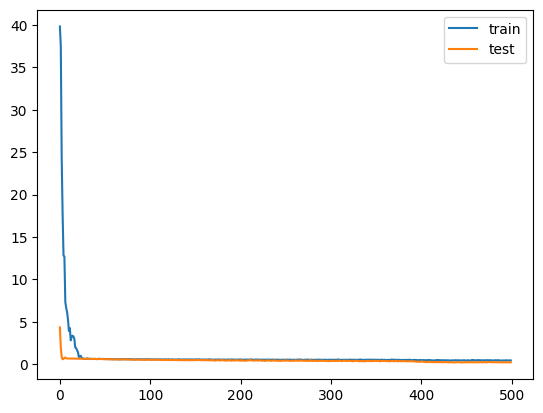

In [45]:
plt.plot(history.history['loss'], label='train')
plt.plot(history.history['val_loss'], label='test')
plt.legend()
plt.show()